# 2주차: 행렬은 변환이다 — 선형 변환과 편향 트릭
**인공지능수학 | Week 02 Lecture**

> **이번 주 목표**
> - 행렬-벡터 곱을 *숫자 계산*이 아니라 *공간 변환*으로 읽을 수 있다
> - Broadcasting이 수학적으로 어떤 규칙인지 이해하고 오류를 예측할 수 있다
> - 아핀 변환 $\hat{y} = \mathbf{w}^T\mathbf{x} + b$를 편향 트릭으로 순수한 행렬 곱으로 바꿀 수 있다

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

---
## 🎯 Aha Moment: 행렬 곱이 이런 일을 한다고?

설명 없이 먼저 보겠습니다. 아래 코드는 격자(grid) 위의 점들에 행렬을 곱합니다.

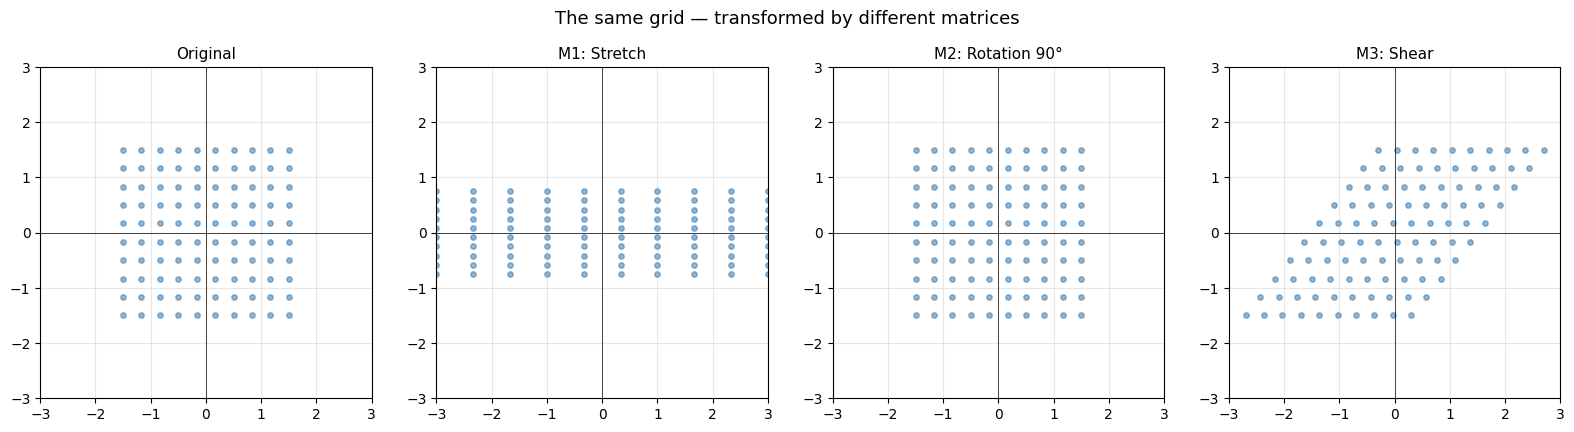

In [ ]:
# ---- Aha Moment: Matrix transforms a grid ----
# Create a grid of points
s = np.linspace(-1.5, 1.5, 10)
grid_x, grid_y = np.meshgrid(s, s)
points = np.stack([grid_x.ravel(), grid_y.ravel()])   # shape (2, 100)

# Three different matrices
M1 = np.array([[2,  0],
               [0,  0.5]])   # stretch

M2 = np.array([[ 0, -1],
               [ 1,  0]])   # 90-degree rotation

M3 = np.array([[1, 0.8],
               [0, 1  ]])   # shear

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'M1: Stretch', 'M2: Rotation 90°', 'M3: Shear']
matrices = [np.eye(2), M1, M2, M3]

for ax, M, title in zip(axes, matrices, titles):
    p = M @ points                      # transform all 100 points at once
    ax.scatter(p[0], p[1], s=15, alpha=0.6, color='steelblue')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('The same grid — transformed by different matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **질문:** 행렬 곱은 그냥 숫자를 섞는 연산 아닌가요?  
> 격자가 왜 이렇게 변하는 걸까요?

> 👉 *이 질문의 답을 이번 수업에서 수학적으로 열겠습니다.*

---
## 1. 행렬-벡터 곱 = 선형 변환

### 1-1. 행렬 곱을 두 가지 방식으로 읽기

1주차에서 행렬 곱을 **행 × 열 내적**으로 배웠습니다.  
이제 같은 연산을 다른 방식으로 읽어봅니다.

$$\mathbf{A}\mathbf{x} = \begin{bmatrix} 2 & 1 \\ 0 & 3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$

**읽는 방법 1 — 행 내적:**
$$= \begin{bmatrix} 2x_1 + 1x_2 \\ 0x_1 + 3x_2 \end{bmatrix}$$

**읽는 방법 2 — 열의 선형결합:**
$$= x_1 \begin{bmatrix} 2 \\ 0 \end{bmatrix} + x_2 \begin{bmatrix} 1 \\ 3 \end{bmatrix}$$

두 번째 읽기가 핵심입니다. **$\mathbf{A}$의 열 벡터들을 $x_1, x_2$만큼 섞어서 새 벡터를 만든다.**

In [ ]:
# ---- Two ways to read matrix-vector multiplication ----
A = np.array([[2, 1],
              [0, 3]])
x = np.array([3.0, 2.0])

# Method 1: row dot product
result_m1 = A @ x

# Method 2: linear combination of columns
col1, col2 = A[:, 0], A[:, 1]
result_m2 = x[0] * col1 + x[1] * col2

print('A @ x (matrix multiply):', result_m1)
print('x1*col1 + x2*col2      :', result_m2)
print('Same result?', np.allclose(result_m1, result_m2))

A @ x (matrix multiply): [8. 6.]
x1*col1 + x2*col2      : [8. 6.]
Same result? True


### 1-2. 선형 변환의 두 가지 성질

행렬 $\mathbf{A}$로 벡터를 변환하는 함수 $f(\mathbf{x}) = \mathbf{A}\mathbf{x}$는 두 가지 성질을 반드시 만족합니다:

**① 덧셈 보존 (Additivity)**
$$f(\mathbf{x} + \mathbf{y}) = f(\mathbf{x}) + f(\mathbf{y})$$

**② 스칼라 곱 보존 (Homogeneity)**
$$f(c\mathbf{x}) = c \cdot f(\mathbf{x})$$

이 두 성질을 만족하는 변환을  **선형 변환(Linear Transformation)** 이라 합니다.  
직관적으로 말하면: **직선은 직선으로, 원점은 원점으로** 유지됩니다.

In [ ]:
# ---- Verify linearity: A(x+y) = Ax + Ay ----
A = np.array([[2, 1], [0, 3]])
x = np.array([3.0, 2.0])
y = np.array([-1.0, 4.0])

lhs = A @ (x + y)          # A(x + y)
rhs = A @ x + A @ y        # Ax + Ay

print('A(x+y)  :', lhs)
print('Ax + Ay :', rhs)
print('Equal?  :', np.allclose(lhs, rhs))

# Homogeneity: A(cx) = c*Ax
c = 5.0
lhs2 = A @ (c * x)
rhs2 = c * (A @ x)
print('\nA(5x)  :', lhs2)
print('5*Ax   :', rhs2)
print('Equal? :', np.allclose(lhs2, rhs2))

A(x+y)  : [10. 18.]
Ax + Ay : [10. 18.]
Equal?  : True

A(5x)  : [40. 30.]
5*Ax   : [40. 30.]
Equal? : True


### 1-3. 기저 벡터로 변환 완전히 이해하기

2차원 공간의 기저 벡터는 $\mathbf{e}_1 = \begin{bmatrix}1\\0\end{bmatrix}$, $\mathbf{e}_2 = \begin{bmatrix}0\\1\end{bmatrix}$입니다.

행렬 $\mathbf{A}$를 곱하면:

$$\mathbf{A}\mathbf{e}_1 = \begin{bmatrix} 2 & 1 \\ 0 & 3 \end{bmatrix}\begin{bmatrix}1\\0\end{bmatrix} = \begin{bmatrix}2\\0\end{bmatrix} = \mathbf{A}\text{의 1열}$$

$$\mathbf{A}\mathbf{e}_2 = \begin{bmatrix} 2 & 1 \\ 0 & 3 \end{bmatrix}\begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}1\\3\end{bmatrix} = \mathbf{A}\text{의 2열}$$

**핵심:** 행렬의 열 벡터 = **기저 벡터가 변환된 결과**  
기저 벡터가 어디로 가는지 알면 전체 공간이 어떻게 변환되는지 알 수 있습니다.

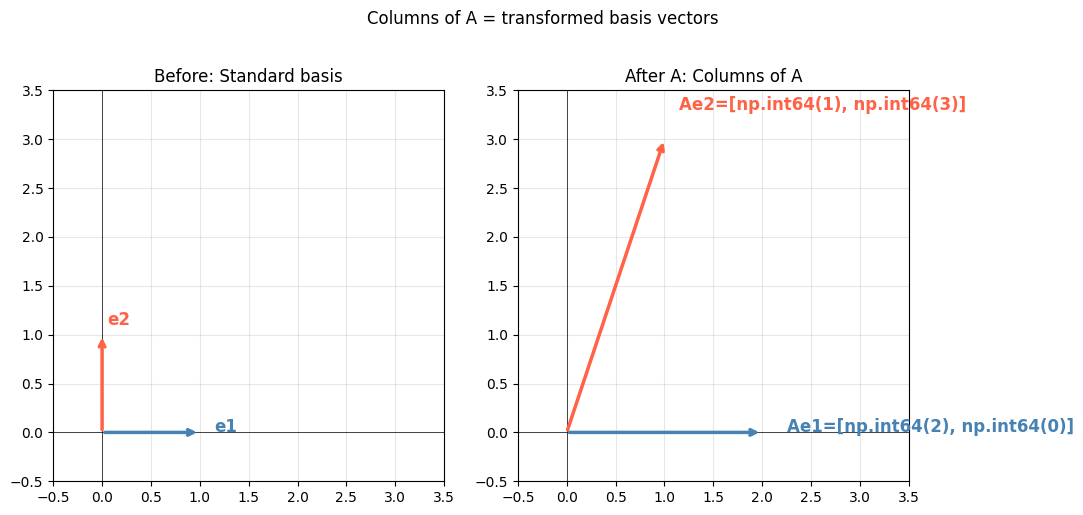

In [ ]:
# ---- Visualize basis vector transformation ----
A = np.array([[2, 1], [0, 3]], dtype=float)
e1 = np.array([1, 0])
e2 = np.array([0, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

def draw_arrow(ax, vec, color, label, start=(0,0)):
    ax.annotate('', xy=(start[0]+vec[0], start[1]+vec[1]), xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(start[0]+vec[0]*1.1+0.05, start[1]+vec[1]*1.1,
            label, color=color, fontsize=12, fontweight='bold')

# Before transformation
ax = axes[0]
draw_arrow(ax, e1, 'steelblue', 'e1')
draw_arrow(ax, e2, 'tomato',    'e2')
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Before: Standard basis', fontsize=12)

# After transformation
ax = axes[1]
Ae1 = A @ e1
Ae2 = A @ e2
draw_arrow(ax, Ae1, 'steelblue', f'Ae1={list(Ae1.astype(int))}')
draw_arrow(ax, Ae2, 'tomato',    f'Ae2={list(Ae2.astype(int))}')
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('After A: Columns of A', fontsize=12)

plt.suptitle('Columns of A = transformed basis vectors', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

이제 Aha Moment로 돌아갑니다.

| &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;행렬&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1열 (e1 → ?)&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2열 (e2 → ?)&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 변환 종류 |
|------|------------|------------|----------|
| $M_1 = \begin{bmatrix}2&0\\0&0.5\end{bmatrix}$ | $(1,0) \to (2,0)$ | $(0,1) \to (0, 0.5)$ | x방향 늘리기, y방향 압축 |
| $M_2 = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$ | $(1,0) \to (0,1)$ | $(0,1) \to (-1,0)$ | 90° 회전 |
| $M_3 = \begin{bmatrix}1&0.8\\0&1\end{bmatrix}$ | $(1,0) \to (1,0)$ | $(0,1) \to (0.8,1)$ | 전단(shear) |

> **규칙:** 행렬의 열 벡터가 기저 벡터의 목적지이고,  
> 나머지 점들은 그 기저를 따라 자동으로 결정됩니다. — 이것이 **선형성**입니다.

---
## 2. Broadcasting — 수학적 규칙

### 2-1. 규칙 정의

NumPy에서 shape이 다른 두 배열을 연산할 때, 아래 두 규칙을 순서대로 적용합니다.

**규칙 1 — 차원 정렬:**  
두 배열의 shape을 오른쪽에서 맞춥니다. 짧은 쪽 왼쪽을 1로 채웁니다.

```
A.shape = (4, 3)     →   (4, 3)
b.shape =    (3,)    →   (1, 3)   ← 왼쪽에 1 추가
```

**규칙 2 — 크기 호환:**  
각 차원에서 두 크기가 **같거나, 둘 중 하나가 1**이면 연산 가능합니다.  
크기가 1인 차원은 상대방 크기에 맞게 **복사**됩니다.

```
(4, 3)   vs   (1, 3)   →   (4, 3)   ✅
(4, 3)   vs   (4, 1)   →   (4, 3)   ✅
(4, 3)   vs   (4, 2)   →   ERROR    ❌  (3 ≠ 2, 둘 다 1이 아님)
```

In [ ]:
# ---- Broadcasting: step by step ----
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10,11,12]])    # shape (4, 3)

b_row = np.array([10, 20, 30])   # shape (3,)  → treated as (1, 3)
b_col = np.array([[10],          # shape (4, 1)
                  [20],
                  [30],
                  [40]])

print('A.shape    :', A.shape)
print('b_row shape:', b_row.shape, '→ broadcast as (1,3)')
print('b_col shape:', b_col.shape)

print('\nA + b_row (add same row to each row):')
print(A + b_row)

print('\nA + b_col (add different value to each column):')
print(A + b_col)

A.shape    : (4, 3)
b_row shape: (3,) → broadcast as (1,3)
b_col shape: (4, 1)

A + b_row (add same row to each row):
[[11 22 33]
 [14 25 36]
 [17 28 39]
 [20 31 42]]

A + b_col (add different value to each column):
[[11 12 13]
 [24 25 26]
 [37 38 39]
 [50 51 52]]


### 2-2. Broadcasting의 수학적 의미

행렬 $\mathbf{A}$에 행 벡터 $\mathbf{b}^T$를 더하는 것:

$$\mathbf{A} + \mathbf{b}^T = \begin{bmatrix} \mathbf{a}_1^T + \mathbf{b}^T \\ \mathbf{a}_2^T + \mathbf{b}^T \\ \vdots \\ \mathbf{a}_m^T + \mathbf{b}^T \end{bmatrix}$$

즉 "각 행에 동일한 벡터를 더한다" — 이것이 broadcasting의 실제 의미입니다.  
나중에 **특성 정규화**(5주차)에서 이 연산이 핵심적으로 사용됩니다.

### 2-3. 오류 예측 연습

아래 연산 전에 오류가 날지 예측해보세요.

In [ ]:
# ---- Predict before running: which will error? ----
A = np.ones((4, 3))

shapes_to_try = [
    np.ones((3,)),         # ?
    np.ones((4,)),         # ?
    np.ones((1, 3)),       # ?
    np.ones((4, 1)),       # ?
    np.ones((4, 3)),       # ?
]

for b in shapes_to_try:
    try:
        result = A + b
        print(f'A{A.shape} + b{b.shape} = result{result.shape}  OK')
    except ValueError as e:
        print(f'A{A.shape} + b{b.shape}  ERROR: {e}')

A(4, 3) + b(3,) = result(4, 3)  OK
A(4, 3) + b(4,)  ERROR: operands could not be broadcast together with shapes (4,3) (4,) 
A(4, 3) + b(1, 3) = result(4, 3)  OK
A(4, 3) + b(4, 1) = result(4, 3)  OK
A(4, 3) + b(4, 3) = result(4, 3)  OK


### 2-4. `np.newaxis` — 명시적으로 차원 추가하기

shape `(4,)` 벡터를 열 벡터 `(4, 1)`로 만드는 방법:

```python
v = np.array([1, 2, 3, 4])      # shape (4,)
v[:, np.newaxis]                 # shape (4, 1)
v.reshape(4, 1)                  # shape (4, 1)  — 같은 결과
```

1주차에서 배운 `(n,)` vs `(n,1)` 구분이 여기서 실용적으로 쓰입니다.

In [12]:
# ---- np.newaxis usage ----
v = np.array([10, 20, 30, 40])   # shape (4,)
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10,11,12]])        # shape (4, 3)

print('v.shape              :', v.shape)
print('v[:,np.newaxis].shape:', v[:, np.newaxis].shape)

# Subtract each row's own value
result = M - v[:, np.newaxis]
print('\nM - v (each row subtracted by its own value):')
print(result)
print('Result shape:', result.shape)

v.shape              : (4,)
v[:,np.newaxis].shape: (4, 1)

M - v (each row subtracted by its own value):
[[ -9  -8  -7]
 [-16 -15 -14]
 [-23 -22 -21]
 [-30 -29 -28]]
Result shape: (4, 3)


In [13]:
print(v[np.newaxis, :])
print(v[:, np.newaxis])

[[10 20 30 40]]
[[10]
 [20]
 [30]
 [40]]


---
## 3. 편향 트릭 — 아핀 변환을 행렬 곱으로

### 3-1. 문제: 선형 모델에 편향이 있다

지금까지 본 선형회귀 모델은 사실 이렇게 생겼습니다:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

$b$는 **편향(bias)** — 입력과 무관하게 더해지는 상수입니다.  
이를 행렬로 쓰면:

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

$b$가 따로 있어서 불편합니다. $\mathbf{w}$와 $b$를 **동시에** 경사하강법으로 업데이트해야 하고, 코드도 복잡해집니다.

### 3-2. 아이디어: 1을 특성으로 추가

각 데이터 샘플에 특성값 $1$을 추가하면:

$$\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \\ 1 \end{bmatrix} \quad \text{(원래 특성 + 상수 1)}$$

가중치 벡터에도 $b$를 추가하면:

$$\mathbf{w}' = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \\ b \end{bmatrix}$$

그러면:

$$\hat{y} = {\mathbf{w}'}^T \mathbf{x}' = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b \cdot 1$$

$$= w_1 x_1 + \cdots + w_n x_n + b \quad ✅$$

편향 $b$가 사라지고, **순수한 내적** 하나로 통합됩니다.

### 3-3. 행렬 전체에 적용

$m$개 샘플이 있을 때, 설계 행렬(design matrix) $\mathbf{X}$에 1열을 앞에 추가합니다:

$$\mathbf{X} = \begin{bmatrix} x_{11} & \cdots & x_{1n} \\ \vdots & & \vdots \\ x_{m1} & \cdots & x_{mn} \end{bmatrix}_{m \times n} \quad \longrightarrow \quad \mathbf{X}' = \begin{bmatrix} 1 & x_{11} & \cdots & x_{1n} \\ \vdots & \vdots & & \vdots \\ 1 & x_{m1} & \cdots & x_{mn} \end{bmatrix}_{m \times (n+1)}$$

그러면 모든 샘플의 예측을 한 번에:

$$\hat{\mathbf{y}} = \mathbf{X}'\mathbf{w}' = \begin{bmatrix} 1 & x_{11} & \cdots & x_{1n} \\ \vdots & & & \vdots \\ 1 & x_{m1} & \cdots & x_{mn} \end{bmatrix} \begin{bmatrix} b \\ w_1 \\ \vdots \\ w_n \end{bmatrix}$$

$b$와 $\mathbf{w}$를 별도로 관리할 필요가 없어집니다.
이를 **편향 트릭(Bias Trick)** 이라 합니다.

In [ ]:
# ---- Bias Trick: verify the math ----
# 3 samples, 2 features
X = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])   # shape (3, 2)

w = np.array([0.5, -1.0])   # feature weights
b = 2.0                      # bias

# --- Without bias trick ---
y_hat_original = X @ w + b

# --- With bias trick ---
ones = np.ones((X.shape[0], 1))         # shape (3, 1)
X_bias = np.hstack([ones, X])           # shape (3, 3): prepend ones column
w_bias = np.concatenate([[b], w])       # shape (3,):  prepend b to w

y_hat_trick = X_bias @ w_bias

print('X_bias (design matrix with bias column):')
print(X_bias)
print('\nw_bias (bias prepended):', w_bias)
print('\nPredictions without trick:', y_hat_original)
print('Predictions with    trick:', y_hat_trick)
print('Identical?', np.allclose(y_hat_original, y_hat_trick))

X_bias (design matrix with bias column):
[[1. 1. 2.]
 [1. 3. 4.]
 [1. 5. 6.]]

w_bias (bias prepended): [ 2.   0.5 -1. ]

Predictions without trick: [ 0.5 -0.5 -1.5]
Predictions with    trick: [ 0.5 -0.5 -1.5]
Identical? True


### 3-4. 왜 중요한가?

편향 트릭이 있으면 경사하강법 코드가 극적으로 단순해집니다:

```python
# Without bias trick: two separate updates
w = w - lr * grad_w
b = b - lr * grad_b

# With bias trick: one update covers everything
w_bias = w_bias - lr * grad_w_bias
```

그리고 더 중요한 것: **편향을 포함한 모델도 순수한 선형 변환의 수학으로 분석**할 수 있게 됩니다.  
이 트릭은 3주차 선형회귀부터 이후 모든 모델에서 사용됩니다.

---
## 4. 세 개념을 하나로 연결하기

이번 주 세 가지 개념이 사실 하나의 이야기입니다:

```
선형 변환
  ↓ "m개 샘플에 동시에 적용"
행렬 곱  Xw
  ↓ "편향도 포함하고 싶다"
편향 트릭  X'w'  (1열 추가)
  ↓ "각 샘플에서 평균을 빼거나, 특성마다 다른 값을 더하고 싶다"
Broadcasting  X - mean(X, axis=0)
```

**구체적인 예시:** 5주차에서 배울 다변수 선형회귀의 전체 파이프라인은 이렇게 됩니다:

```python
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)   # broadcasting: 정규화
X_bias = np.hstack([np.ones((m, 1)), X_norm])    # bias trick
y_hat  = X_bias @ w                              # linear transform
```

지금 이 세 줄의 **수학적 의미**를 전부 이해하셨습니다.

In [ ]:
# ---- Aha Moment 닫기: 처음 격자 변환을 다시 보기 ----
# M2 = 90-degree rotation matrix
M2 = np.array([[ 0, -1],
               [ 1,  0]])

# e1 goes to...
print('e1 = [1,0] → M2 @ e1 =', M2 @ np.array([1,0]))
print('  → This is the 1st column of M2:', M2[:,0])

# e2 goes to...
print('\ne2 = [0,1] → M2 @ e2 =', M2 @ np.array([0,1]))
print('  → This is the 2nd column of M2:', M2[:,1])

print('\n결론: e1이 (0,1)로, e2가 (-1,0)으로 → 반시계 90° 회전')
print('행렬의 두 열을 보면 변환 전체를 알 수 있습니다.')

e1 = [1,0] → M2 @ e1 = [0 1]
  → This is the 1st column of M2: [0 1]

e2 = [0,1] → M2 @ e2 = [-1  0]
  → This is the 2nd column of M2: [-1  0]

결론: e1이 (0,1)로, e2가 (-1,0)으로 → 반시계 90° 회전
행렬의 두 열을 보면 변환 전체를 알 수 있습니다.


---
## ✏️ 익히기 활동 (25분)

### 문제 1: Broadcasting 규칙 적용 (8분)

아래 코드를 실행하기 **전에** 결과를 예측하고, 빈칸을 채우세요.

In [2]:
# Problem 1: Predict the output before running
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])    # shape (3, 2)

b = np.array([10, 20])   # shape (2,)

# (a) What is the output shape?
# Prediction: (3, 2)
# (b) What are the values?
# Prediction:
# [[11, 22]
#  [13, 24]
#  [15, 26]]

print('A + b =')
print(A + b)

# (c) Now try: subtract column-wise mean from each column
col_mean = A.mean(axis=0)   # shape: (1, 2)
print('\ncol_mean:', col_mean, '  shape:', col_mean.shape)

A_centered = A - col_mean     # fill in
print('A_centered ='); print(A_centered)
print('Column means after centering:', A_centered.mean(axis=0))

A + b =
[[11 22]
 [13 24]
 [15 26]]

col_mean: [3. 4.]   shape: (2,)
A_centered =
[[-2. -2.]
 [ 0.  0.]
 [ 2.  2.]]
Column means after centering: [0. 0.]


### 문제 2: 편향 트릭 완성 (7분)

아래 빈칸을 채워 편향 트릭이 올바르게 작동하게 하세요.

In [3]:
# Problem 2: Complete the bias trick
np.random.seed(0)
X = np.random.randn(5, 3)    # 5 samples, 3 features
w = np.array([1.0, -2.0, 0.5])  # 3 weights
b = 3.0                           # bias

# Reference (without trick)
y_ref = X @ w + b

# With bias trick — fill in the blanks
m = X.shape[0]
X_bias = np.hstack([np.ones((5, 1)), X])              # prepend ones column
w_bias = np.concatenate([[b], w])       # prepend b

y_trick = X_bias @ w_bias

print('X_bias shape:', X_bias.shape)   # should be (5, 4)
print('w_bias:', w_bias)               # should be [3. 1. -2. 0.5]
print('Match?', np.allclose(y_ref, y_trick))

X_bias shape: (5, 4)
w_bias: [ 3.   1.  -2.   0.5]
Match? True


### 🐛 버그 문제 (10분)

아래 코드는 오류 없이 실행되지만 결과가 틀립니다.  
무엇이 잘못됐는지 찾고, 원인을 수학적으로 설명하세요.

*교실에서 팀 활동으로 해결합니다.*

In [10]:
# 🐛 Bug Hunt: runs without error, but gives wrong predictions
X = np.array([[2.0, 3.0],
              [4.0, 1.0],
              [6.0, 5.0]])   # shape (3, 2), 3 samples, 2 features

w = np.array([0.5, -1.0])   # feature weights
b = 1.0

# Attempt bias trick
ones = np.ones(3)
ones = np.ones((3,1))                        # 🐛 shape?
X_bias = np.hstack([ones, X])           # 🐛 what shape does this produce?
w_bias = np.concatenate([[b], w])

print('ones.shape  :', ones.shape)
print('X_bias.shape:', X_bias.shape)
print('w_bias      :', w_bias)

# This will error or give wrong shape
try:
    result = X_bias @ w_bias
    print('Result:', result)
    print('Expected:', X @ w + b)
except Exception as e:
    print('ERROR:', e)

# 버그 원인:  hstack하는 ones가 1차원배열, 행렬이 아니었음
# 수정 방법:  reshape함수 사용하거나, ones 생성시에 (3, 1)로 생성

ones.shape  : (3, 1)
X_bias.shape: (3, 3)
w_bias      : [ 1.   0.5 -1. ]
Result: [-1.  2. -1.]
Expected: [-1.  2. -1.]


---
## 🤖 LLM 파트너 가이드

### 프롬프트 1: 선형 변환 직관 확인
```
행렬 [[3, 0], [0, -1]]이 2D 공간을 어떻게 변환하는지 설명해주세요.
기저 벡터 e1, e2가 어디로 이동하는지를 중심으로,
시각적으로 상상할 수 있게 설명해 주세요.
```

### 프롬프트 2: Broadcasting 오류 디버깅
```
다음 코드에서 ValueError가 발생합니다.
답을 바로 알려주지 말고, 제가 shape을 직접 확인해볼 수 있는
디버깅 단계를 알려주세요.
[코드 붙여넣기]
```

### 프롬프트 3: 편향 트릭 수학 확인
```
편향 트릭에서 np.ones((m,1))을 사용해야 하는데
np.ones(m)을 쓰면 어떤 shape 문제가 생기는지
np.hstack 동작과 연결해서 설명해주세요.
```

> **원칙:** 코드 오류를 LLM에 바로 던지지 말고,  
> 먼저 **shape을 직접 print**해서 문제를 좁힌 뒤 물어보세요.

---
## 📌 다음 주 예고: 선형회귀 — 오차를 최소화하는 $\mathbf{w}$를 찾는다

이번 주에 배운 편향 트릭과 행렬 곱을 그대로 사용해서,  
**주어진 데이터를 가장 잘 설명하는 직선(초평면)**을 수학적으로 구합니다.

핵심 질문: $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$에서 $\mathbf{y}$와 가장 가까운 $\mathbf{w}$를 어떻게 찾을까요?